## Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
df = pd.read_csv('../data/telco_churn.csv')

# First look
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum().sum()}")
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Missing values:
0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges — it's stored as string, should be numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

## EDA

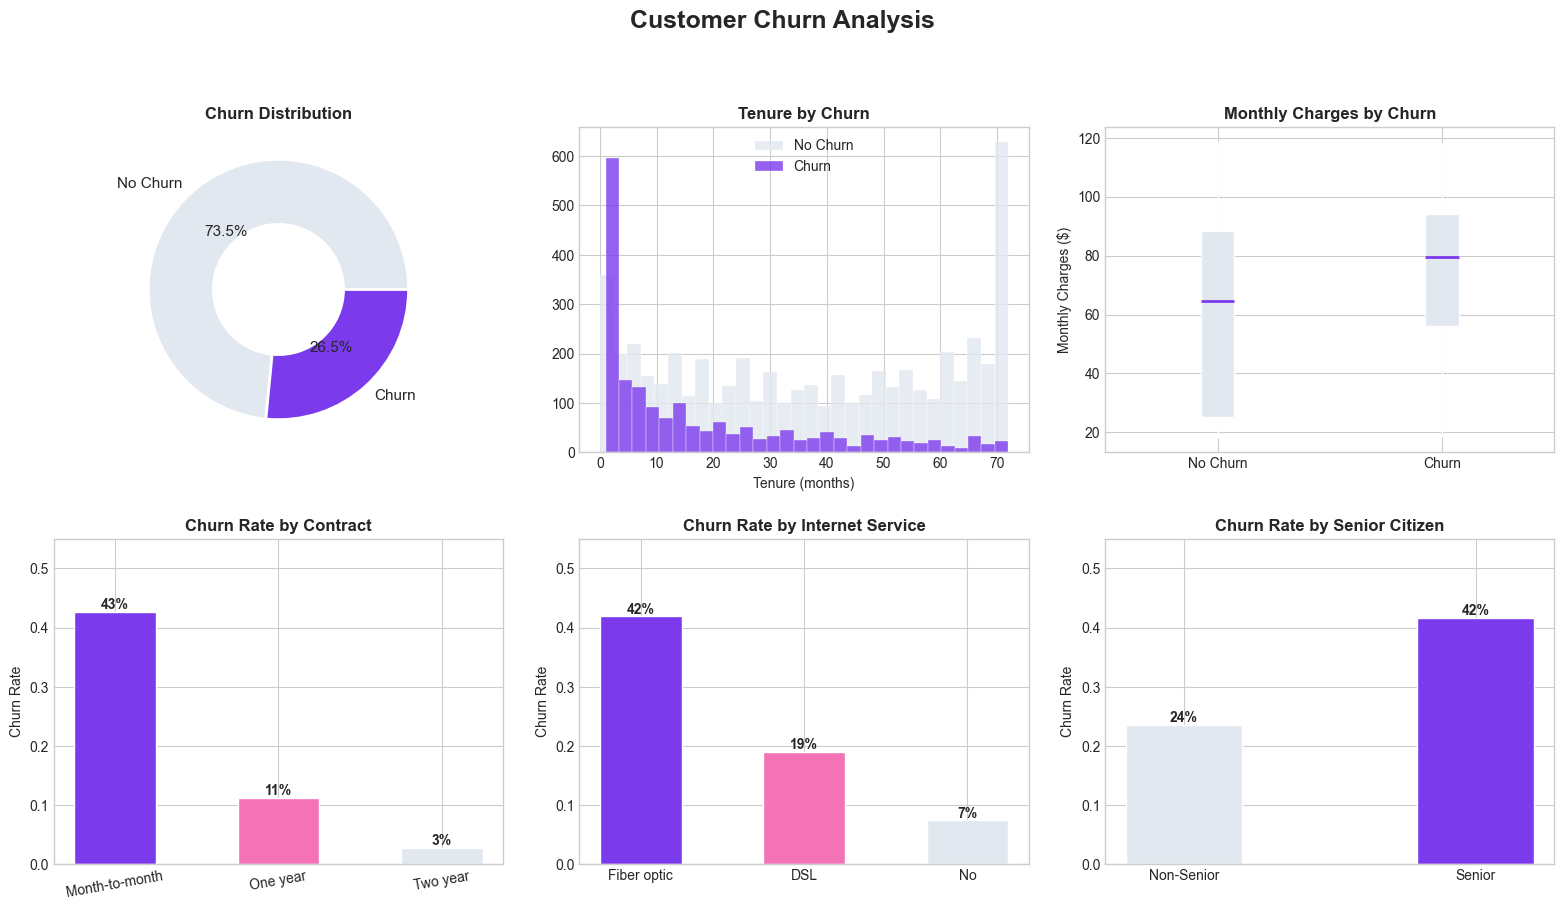

EDA complete.


In [8]:
plt.style.use('seaborn-v0_8-whitegrid')
PURPLE = '#7C3AED'
PINK   = '#F472B6'
GRAY   = '#E2E8F0'

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Customer Churn Analysis', fontsize=18, fontweight='bold', y=1.02)

# 1. Churn distribution
axes[0,0].pie([5174, 1869], labels=['No Churn', 'Churn'],
              autopct='%1.1f%%', colors=[GRAY, PURPLE],
              wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
              textprops={'fontsize': 11})
axes[0,0].set_title('Churn Distribution', fontweight='bold')

# 2. Tenure by Churn
for val, color, label in [(0, GRAY, 'No Churn'), (1, PURPLE, 'Churn')]:
    axes[0,1].hist(df[df['Churn']==val]['tenure'], bins=30,
                   alpha=0.8, color=color, label=label, edgecolor='white', linewidth=0.3)
axes[0,1].set_title('Tenure by Churn', fontweight='bold')
axes[0,1].set_xlabel('Tenure (months)')
axes[0,1].legend()

# 3. Monthly Charges by Churn
axes[0,2].boxplot([df[df['Churn']==0]['MonthlyCharges'],
                   df[df['Churn']==1]['MonthlyCharges']],
                  labels=['No Churn', 'Churn'],
                  patch_artist=True,
                  boxprops=dict(facecolor=GRAY),
                  medianprops=dict(color=PURPLE, linewidth=2))
axes[0,2].set_title('Monthly Charges by Churn', fontweight='bold')
axes[0,2].set_ylabel('Monthly Charges ($)')

# 4. Contract type
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = axes[1,0].bar(contract_churn.index, contract_churn.values,
                     color=[PURPLE, PINK, GRAY], edgecolor='white', width=0.5)
for bar, val in zip(bars, contract_churn.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.0%}', ha='center', fontweight='bold', fontsize=10)
axes[1,0].set_title('Churn Rate by Contract', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].set_ylim(0, 0.55)
axes[1,0].tick_params(axis='x', rotation=10)

# 5. Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
bars = axes[1,1].bar(internet_churn.index, internet_churn.values,
                     color=[PURPLE, PINK, GRAY], edgecolor='white', width=0.5)
for bar, val in zip(bars, internet_churn.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.0%}', ha='center', fontweight='bold', fontsize=10)
axes[1,1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[1,1].set_ylabel('Churn Rate')
axes[1,1].set_ylim(0, 0.55)

# 6. Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean()
bars = axes[1,2].bar(['Non-Senior', 'Senior'], senior_churn.values,
                     color=[GRAY, PURPLE], edgecolor='white', width=0.4)
for bar, val in zip(bars, senior_churn.values):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                   f'{val:.0%}', ha='center', fontweight='bold', fontsize=10)
axes[1,2].set_title('Churn Rate by Senior Citizen', fontweight='bold')
axes[1,2].set_ylabel('Churn Rate')
axes[1,2].set_ylim(0, 0.55)

plt.tight_layout(pad=2.0)
plt.savefig('../model/eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA complete.")

## Feature Engineering & Preprocessing

In [9]:
# Drop customerID — not a feature
df = df.drop(columns=['customerID'])

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# One-hot encode multi-class columns
X = pd.get_dummies(X, columns=['InternetService', 'Contract', 'PaymentMethod'],
                   drop_first=True)

# Scale numeric columns
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[num_cols] = scaler.fit_transform(X[num_cols])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features:     {X.columns.tolist()}")

Training set: (5634, 23)
Test set:     (1409, 23)
Features:     ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


## Train Models

In [10]:
# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

In [11]:
# ── Random Forest ──
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

In [12]:
# ── Results Summary ──
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")

print("\n" + "=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=['No Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

ROC-AUC: 0.8423

RANDOM FOREST
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.87      1035
       Churn       0.65      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

ROC-AUC: 0.8247


## Model Evaluation Visuals

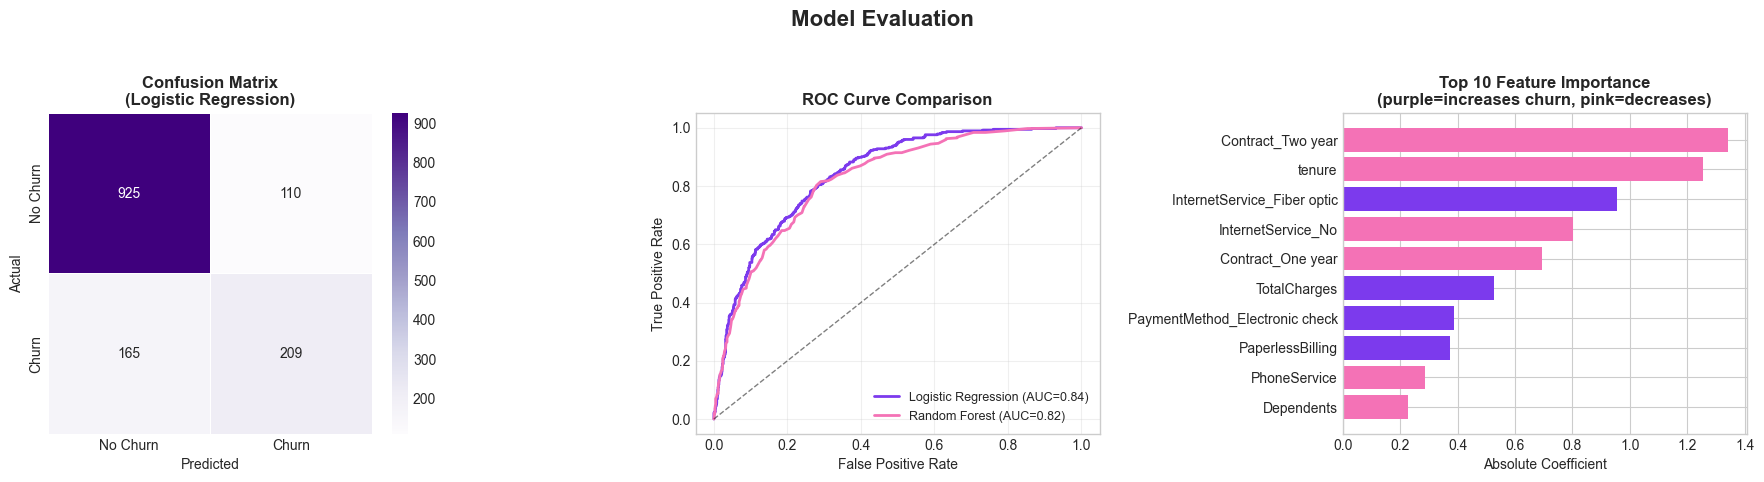

Evaluation complete.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
cm = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            cmap='Purples', linewidths=0.5,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Confusion Matrix\n(Logistic Regression)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve — both models
for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC=0.84)', PURPLE),
    (rf_probs, f'Random Forest (AUC=0.82)',       PINK)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=label)
axes[1].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5)
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Feature Importance (top 10)
importance = pd.Series(lr.coef_[0], index=X.columns)
top10 = importance.abs().sort_values(ascending=True).tail(10)
colors = [PURPLE if importance[i] > 0 else PINK for i in top10.index]
axes[2].barh(top10.index, top10.values, color=colors, edgecolor='none')
axes[2].set_title('Top 10 Feature Importance\n(purple=increases churn, pink=decreases)',
                  fontweight='bold')
axes[2].set_xlabel('Absolute Coefficient')

plt.tight_layout(pad=2.0)
plt.savefig('../model/evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Evaluation complete.")

## Business Framing

In [14]:
print("""
╔══════════════════════════════════════════════════════════════╗
║           WHAT WOULD I ACTUALLY DO WITH THIS?               ║
╚══════════════════════════════════════════════════════════════╝

MODEL PERFORMANCE SUMMARY
─────────────────────────
- ROC-AUC: 0.84 — the model correctly ranks churners above 
  non-churners 84% of the time
- Precision on Churn: 66% — when we flag someone as at-risk,
  we're right 2 out of 3 times
- Recall on Churn: 56% — we catch 56% of actual churners
  before they leave

THE BUSINESS PROBLEM
─────────────────────────
Acquiring a new customer costs 5-7x more than retaining one.
With 26.5% churn rate across 7,043 customers, that's ~1,869
customers leaving per cycle.

If average revenue per customer = $65/month:
  → Revenue at risk = 1,869 × $65 = $121,485/month

WHAT THE MODEL ENABLES
─────────────────────────
Instead of treating all 7,043 customers the same, the model
lets us rank customers by churn probability and intervene
selectively.

Top 500 highest-risk customers flagged by model:
  → Estimated ~330 are true churners (66% precision)
  → A $20 retention offer costs: 500 × $20 = $10,000
  → Revenue saved: 330 × $65 = $21,450/month
  → Net ROI: +$11,450/month from targeted intervention alone

3 STRATEGIC RECOMMENDATIONS
─────────────────────────────
1. PRIORITIZE CONTRACT UPGRADES
   Month-to-month customers churn at 43% vs 3% for two-year.
   Offer incentives (1-2 months free) to lock in annual contracts
   for high-risk month-to-month customers.

2. INVESTIGATE FIBER OPTIC PRICING
   Fiber optic customers churn at 42% — nearly double DSL.
   This signals a price-value mismatch. Survey churned fiber
   customers to identify whether speed, reliability, or cost
   is the core issue.

3. NEW CUSTOMER ONBOARDING PROGRAM
   Churn spikes in the first 10 months of tenure.
   A structured 90-day onboarding program with check-ins at
   day 30, 60, and 90 could meaningfully reduce early attrition.
""")


╔══════════════════════════════════════════════════════════════╗
║           WHAT WOULD I ACTUALLY DO WITH THIS?               ║
╚══════════════════════════════════════════════════════════════╝

MODEL PERFORMANCE SUMMARY
─────────────────────────
- ROC-AUC: 0.84 — the model correctly ranks churners above 
  non-churners 84% of the time
- Precision on Churn: 66% — when we flag someone as at-risk,
  we're right 2 out of 3 times
- Recall on Churn: 56% — we catch 56% of actual churners
  before they leave

THE BUSINESS PROBLEM
─────────────────────────
Acquiring a new customer costs 5-7x more than retaining one.
With 26.5% churn rate across 7,043 customers, that's ~1,869
customers leaving per cycle.

If average revenue per customer = $65/month:
  → Revenue at risk = 1,869 × $65 = $121,485/month

WHAT THE MODEL ENABLES
─────────────────────────
Instead of treating all 7,043 customers the same, the model
lets us rank customers by churn probability and intervene
selectively.

Top 500 highest

## Save Model

In [15]:
import pickle
import os

os.makedirs('../model', exist_ok=True)

# Save model, scaler and feature columns
with open('../model/churn_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('../model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../model/feature_columns.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully.")
print(f"Files in model folder: {os.listdir('../model')}")

Model saved successfully.
Files in model folder: ['churn_model.pkl', 'eda_charts.png', 'evaluation_charts.png', 'feature_columns.pkl', 'scaler.pkl']
